In [1]:
from utils import *
from torch.utils.data import TensorDataset, DataLoader
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Input
from tensorflow.keras.losses import Huber
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Bidirectional, LSTM 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import Callback
import time
import json

Using cuda (NVIDIA GeForce RTX 2060)


In [ ]:
# load data
df = load_df()
# calcula las fechas de los datasets de TRAIN, VAL y TEST
dates = calulate_train_validation_test_dates(df)
# scale df
df_scaled, target_scaler = scale_df(df, dates)
# create rolling window for all features
df_scaled_window = window_df(df_scaled)
# split in train / validation / test
df_scaled_window_train, df_scaled_window_validation, df_scaled_window_test = split_df(df_scaled_window, dates)
# create tensors 3d: (batch_size, sequence_length, n_features), (batch_size, 1)
X_train, y_train = to_tensor3d_df(df_scaled_window_train) 
X_validation, y_validation = to_tensor3d_df(df_scaled_window_validation)
X_test, y_test = to_tensor3d_df(df_scaled_window_test)
# log
print(X_train.shape) # expected: (batch_size, sequence_length, n_features)
print(y_train.shape) # expected  (batch_size, 1)
print(f"{y_train.mean():.8f}", f"{y_train.std():.8f}")
print(f"{y_validation.mean():.8f}", f"{y_validation.std():.8f}")
print(f"{y_test.mean():.8f}", f"{y_test.std():.8f}")


torch.Size([24406, 64, 15])
torch.Size([24406])
0.00053956 0.99916416
0.01545069 0.79186475
0.00306685 0.88971955


In [ ]:
# random predictor
class RandomDirection(nn.Module):
    def __init__(self, probs=None, device="cpu"):
        super().__init__()
        if probs is None:
            # default uniform over [-1, 0, 1]
            self.probs = torch.tensor([1/3, 1/3, 1/3], device=device)
        else:
            self.probs = torch.tensor(probs, device=device)
        self.classes = torch.tensor([-1, 0, 1], device=device)
        self.seed = 2

    def forward(self, x):
        #B = x.size(0)
        #idx = torch.multinomial(self.probs, B, replacement=True)
        #return self.classes[idx].unsqueeze(1)  # shape (B,1)
        if self.seed is not None:
            g = torch.Generator(device=x.device)
            g.manual_seed(self.seed)
            idx = torch.multinomial(self.probs, x.size(0), replacement=True, generator=g)
        else:
            idx = torch.multinomial(self.probs, x.size(0), replacement=True)
        return self.classes[idx].unsqueeze(1)

    

In [ ]:
# hyperparams

# compile
model = RandomDirection()

# start 
start = time.time()

# measure 
end = time.time()
metrics = {}
metrics["train_ms"] = (end - start)


In [ ]:
# predict

y_train_predict = model(X_train)

y_validation_predict = model(X_validation)

start = time.time()
y_test_predict = model(X_test)
metrics["test_predict_ms"] = (time.time() - start)

# append results to dataframes 
add_predictions_to_df(df_scaled_window_train, y_train_predict.squeeze(), target_scaler, df_scaled_window_train.iloc[0]["close"])
add_predictions_to_df(df_scaled_window_validation, y_validation_predict.squeeze(), target_scaler, df_scaled_window_validation.iloc[0]["close"])
add_predictions_to_df(df_scaled_window_test, y_test_predict.squeeze(), target_scaler, df_scaled_window_validation.iloc[-1]["predict_close_accumulated"])

# show
df_scaled_window_test


close  close_scaled_t-63  close_scaled_t-62  \
datetime                                                                
2024-05-26 00:00:00  374.447253           1.640060           1.642834   
2024-05-26 01:00:00  374.447253           1.642834           1.645386   
2024-05-26 02:00:00  374.447253           1.645386           1.646487   
2024-05-26 03:00:00  374.447253           1.646487           1.642115   
2024-05-26 04:00:00  374.447253           1.642115           1.643126   
...                         ...                ...                ...   
2024-12-31 18:00:00  475.395843           2.321147           2.321147   
2024-12-31 19:00:00  476.654662           2.321147           2.321147   
2024-12-31 20:00:00  475.328246           2.321147           2.321147   
2024-12-31 21:00:00  475.588699           2.321147           2.321147   
2024-12-31 22:00:00  475.684912           2.321147           2.321147   

                     close_scaled_t-61  close_scaled_t-60  close_scaled_t-59  \
datetime                                                                       
2024-05-26 00:00:00           1.645386           1.646487           1.642115   
2024-05-26 01:00:00           1.646487           1.642115           1.643126   
2024-05-26 02:00:00           1.642115           1.643126           1.656197   
2024-05-26 03:00:00           1.643126           1.656197           1.652596   
2024-05-26 04:00:00           1.656197           1.652596           1.638999   
...                                ...                ...                ...   
2024-12-31 18:00:00           2.321147           2.321147           2.321147   
2024-12-31 19:00:00           2.321147           2.321147           2.321147   
2024-12-31 20:00:00           2.321147           2.321147           2.321147   
2024-12-31 21:00:00           2.321147           2.321147           2.321147   
2024-12-31 22:00:00           2.321147           2.321147           2.321147   

                     close_scaled_t-58  close_scaled_t-57  close_scaled_t-56  \
datetime                                                                       
2024-05-26 00:00:00           1.643126           1.656197           1.652596   
2024-05-26 01:00:00           1.656197           1.652596           1.638999   
2024-05-26 02:00:00           1.652596           1.638999           1.625612   
2024-05-26 03:00:00           1.638999           1.625612           1.629539   
2024-05-26 04:00:00           1.625612           1.629539           1.624874   
...                                ...                ...                ...   
2024-12-31 18:00:00           2.321147           2.321147           2.321147   
2024-12-31 19:00:00           2.321147           2.321147           2.321147   
2024-12-31 20:00:00           2.321147           2.321147           2.321147   
2024-12-31 21:00:00           2.321147           2.321147           2.321147   
2024-12-31 22:00:00           2.321147           2.321147           2.321147   

                     close_scaled_t-55  close_scaled_t-54  close_scaled_t-53  \
datetime                                                                       
2024-05-26 00:00:00           1.638999           1.625612           1.629539   
2024-05-26 01:00:00           1.625612           1.629539           1.624874   
2024-05-26 02:00:00           1.629539           1.624874           1.625366   
2024-05-26 03:00:00           1.624874           1.625366           1.630043   
2024-05-26 04:00:00           1.625366           1.630043           1.629397   
...                                ...                ...                ...   
2024-12-31 18:00:00           2.321147           2.321147           2.321147   
2024-12-31 19:00:00           2.321147           2.321147           2.321147   
2024-12-31 20:00:00           2.321147           2.321147           2.321147   
2024-12-31 21:00:00           2.321147           2.321147           2.321147   
2024-12-31 22:00:00           2.32

In [6]:
# eval metrics
metrics["train"] = evaluate_metrics_df(df_scaled_window_train)
metrics["validation"] = evaluate_metrics_df(df_scaled_window_validation)
metrics["test"] = evaluate_metrics_df(df_scaled_window_test)

# show
print(json.dumps(metrics, indent=4) )


{
    "train_ms": 0.0,
    "test_predict_ms": 0.0,
    "train": {
        "mse": 1.0927062361026733e-05,
        "rmse": 0.0033056107394892602,
        "mae": 0.0024670824346352954,
        "huber": 5.463531180513367e-06,
        "r2": -0.6610149338609832,
        "mape": null,
        "smape": null,
        "aic": null,
        "bic": null,
        "pearson_r": 0.004521448878513034,
        "spearman_rho": 0.0036653311178414753,
        "direction": 33.36064902073261,
        "sharpe": 0.004391636762999113
    },
    "validation": {
        "mse": 8.491257803244956e-06,
        "rmse": 0.002913976287351178,
        "mae": 0.0022232992971552372,
        "huber": 4.245628901622478e-06,
        "r2": -1.0553182346257808,
        "mape": null,
        "smape": null,
        "aic": null,
        "bic": null,
        "pearson_r": 0.0031209144023199176,
        "spearman_rho": 0.022983976580131467,
        "direction": 34.1934250764526,
        "sharpe": 0.002458932927543052
    },
    "test

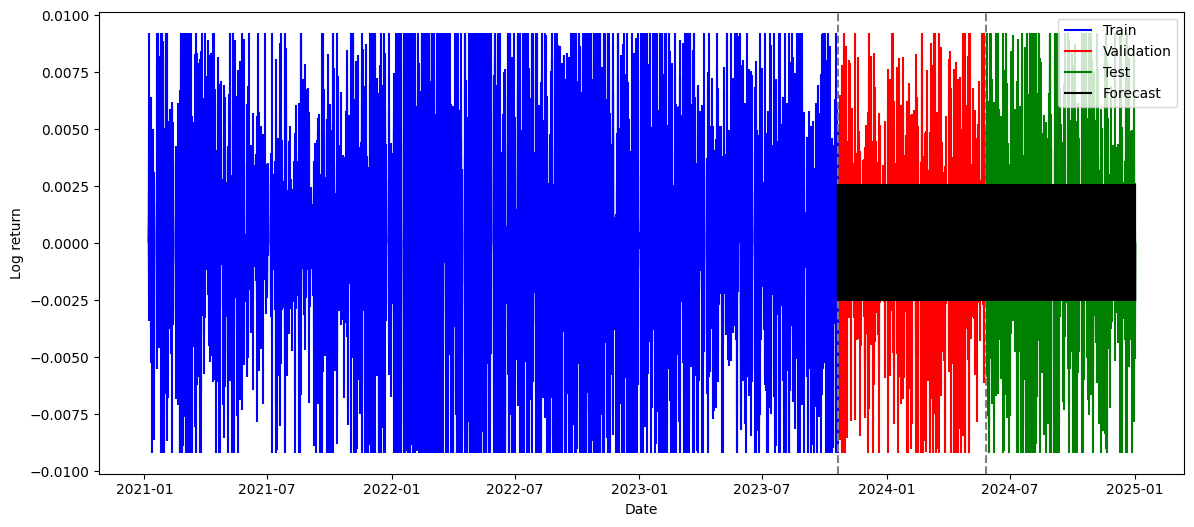

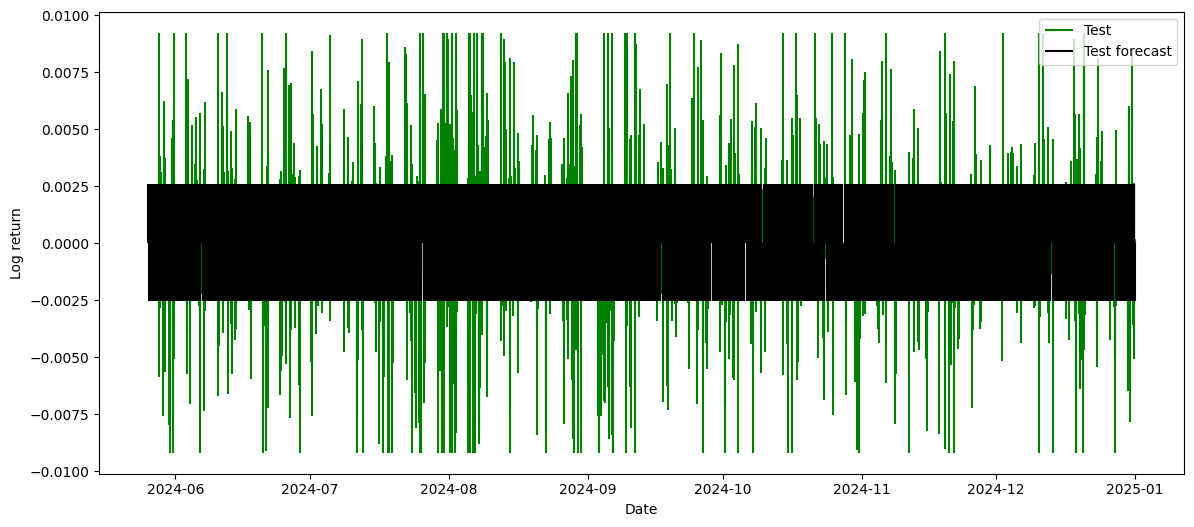

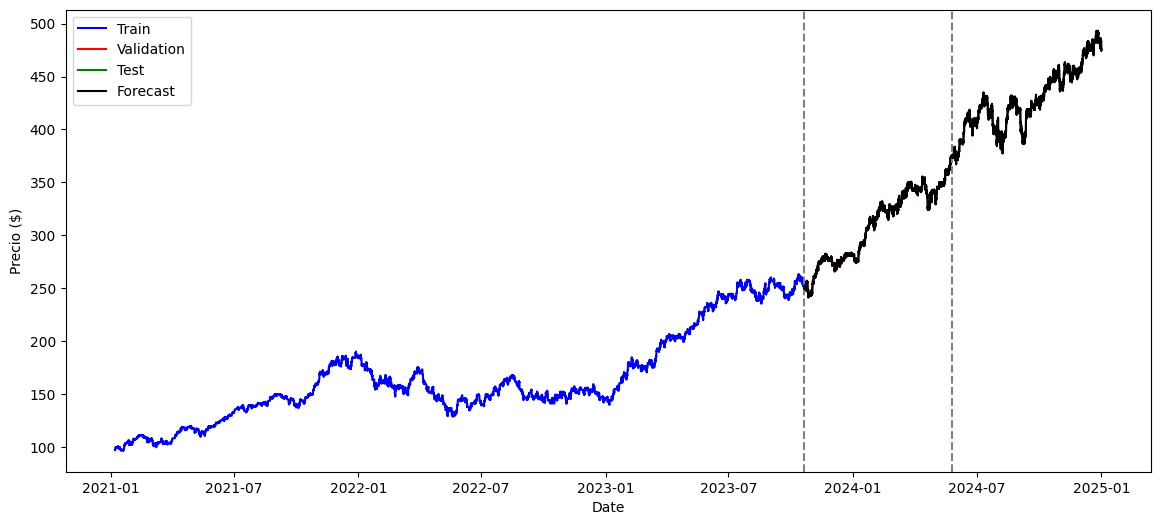

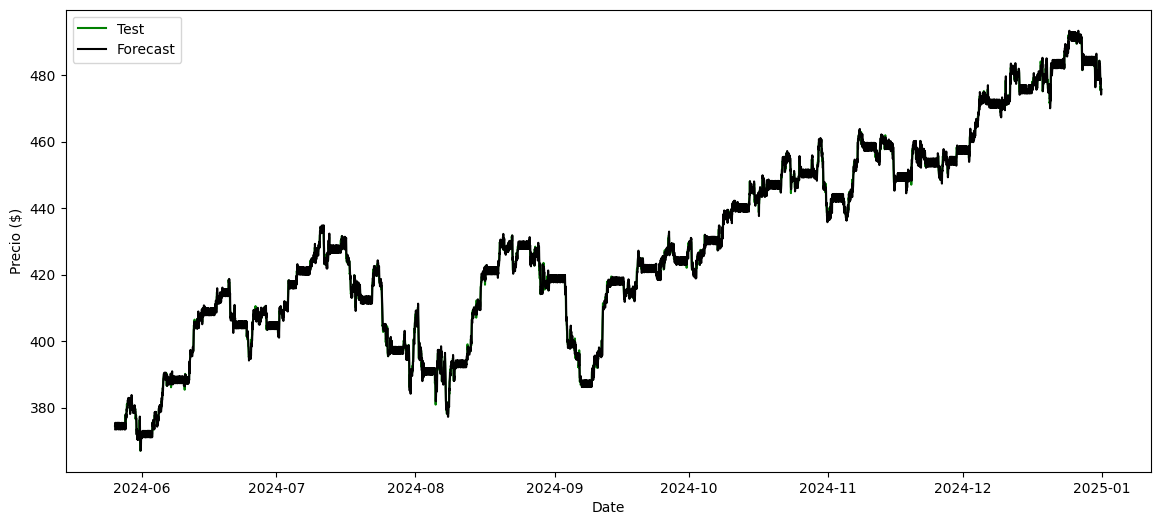

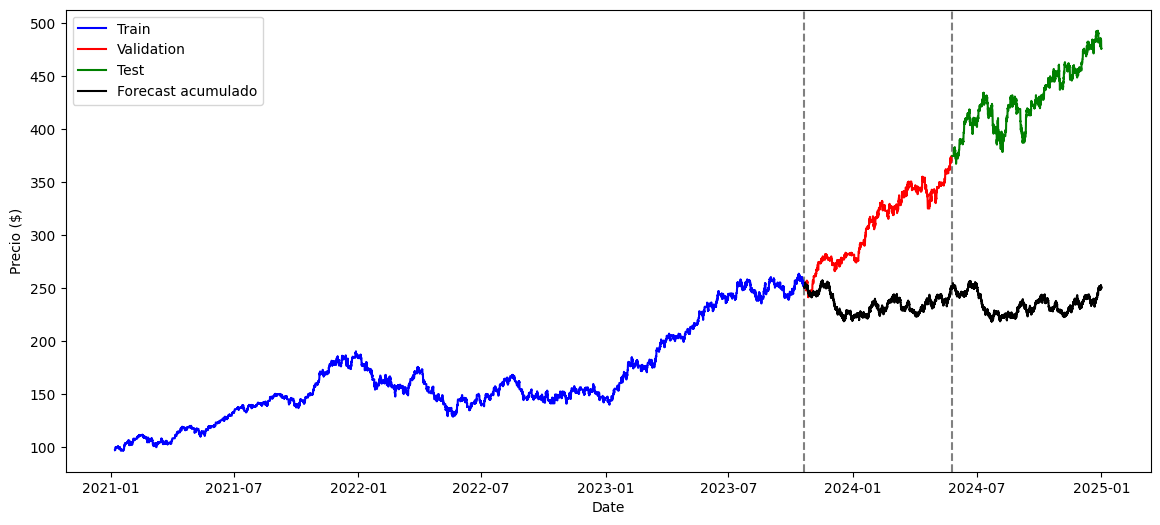

In [7]:
# plot
plot_df(df_scaled_window_train, df_scaled_window_validation, df_scaled_window_test, False)



In [8]:
# Suppose y_dir contains your direction labels (-1, 0, +1)
unique, counts = np.unique(df_scaled_window_test[["target_direction"]].to_numpy(), return_counts=True)
probs = counts / counts.sum()

print("Class distribution:")
for u, p in zip(unique, probs):
    print(f"{u}: {p:.2%}")

# Suppose y_dir contains your direction labels (-1, 0, +1)
unique, counts = np.unique(df_scaled_window_test[["predict_direction"]].to_numpy(), return_counts=True)
probs = counts / counts.sum()

print("Class distribution PREDICT:")
for u, p in zip(unique, probs):
    print(f"{u}: {p:.2%}")    

Class distribution:
-1: 20.52%
0: 56.75%
1: 22.73%
Class distribution PREDICT:
-1: 33.98%
0: 33.49%
1: 32.53%


In [9]:
from scipy.stats import f_oneway

anova_result = f_oneway(
    df_scaled_window_train["error_log_return_square"],
    df_scaled_window_validation["error_log_return_square"],
    df_scaled_window_test["error_log_return_square"]
)

print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)



F-statistic: 37.74568784419929
p-value: 4.216506950473502e-17


In [10]:
# save 
save_result("baseline_random_uniform", metrics, df_scaled_window_train, df_scaled_window_validation, df_scaled_window_test)